# Ejercicio 1 — Dataset Iris

El dataset contiene información sobre 150 flores de iris de tres especies (*setosa*, *versicolor* y *virginica*). Se midieron cuatro características: longitud y ancho del sépalo, y longitud y ancho del pétalo.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='ticks')

data_iris = pd.read_csv('../Datasets/iris.csv')
data_iris.head()

,id,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


## Ítem 1 — Histograma del ancho de sépalo

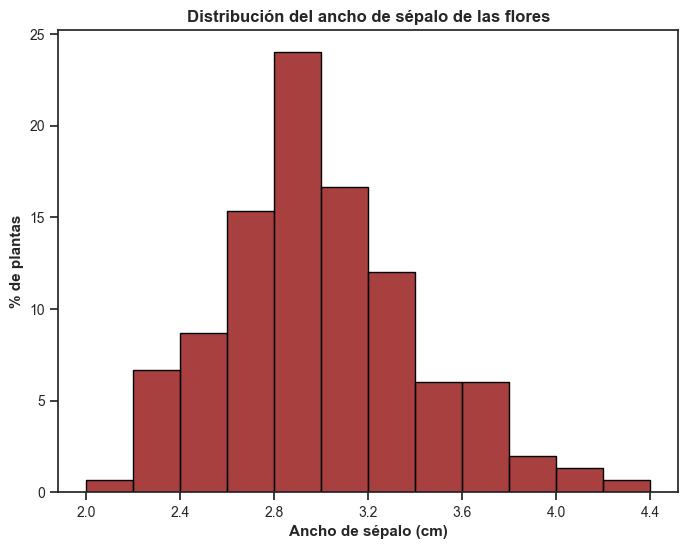

In [2]:
plt.figure(figsize=(8, 6))
sns.histplot(x='sepal_width_cm', fill=True, stat='percent', color='darkred',
             edgecolor='black', data=data_iris, bins=np.arange(2, 4.5, 0.2))
plt.xlabel('Ancho de sépalo (cm)', fontweight='bold', fontsize=11)
plt.title('Distribución del ancho de sépalo de las flores', fontweight='bold')
plt.xticks(np.arange(2, 4.5, 0.4), fontsize=10)
plt.yticks(fontsize=10)
plt.ylabel('% de plantas', fontweight='bold', fontsize=11)
plt.show()

## Ítem 2 — Boxplot múltiple: largo del pétalo por especie

C:\Users\PC\AppData\Local\Temp\ipykernel_16252\3143020282.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='species', y='petal_length_cm', data=data_iris, palette='muted')


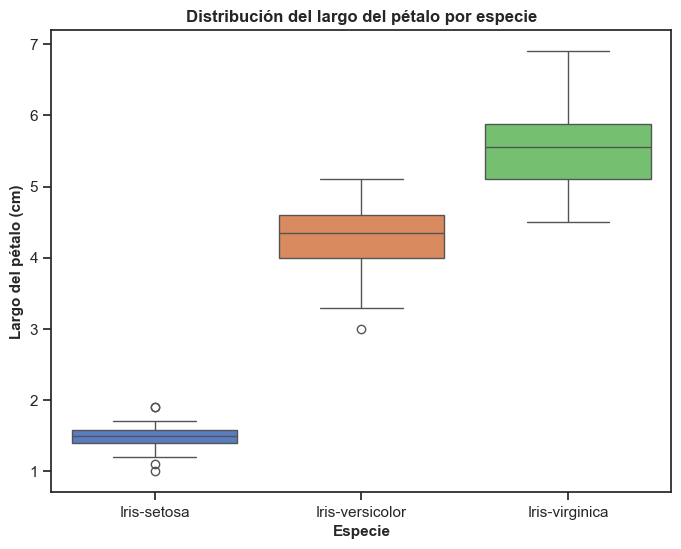

In [3]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='species', y='petal_length_cm', data=data_iris, palette='muted')
plt.xlabel('Especie', fontweight='bold', fontsize=11)
plt.ylabel('Largo del pétalo (cm)', fontweight='bold', fontsize=11)
plt.title('Distribución del largo del pétalo por especie', fontweight='bold')
plt.show()

**Observación:** La especie *virginica* presenta la mayor mediana del largo del pétalo, seguida de *versicolor* y finalmente *setosa*, que muestra valores notablemente más bajos y poca dispersión.

## Ítem 3 — Boxplot con media superpuesta

C:\Users\PC\AppData\Local\Temp\ipykernel_16252\2165610741.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='species', y='petal_length_cm', data=data_iris, palette='muted', ax=ax)


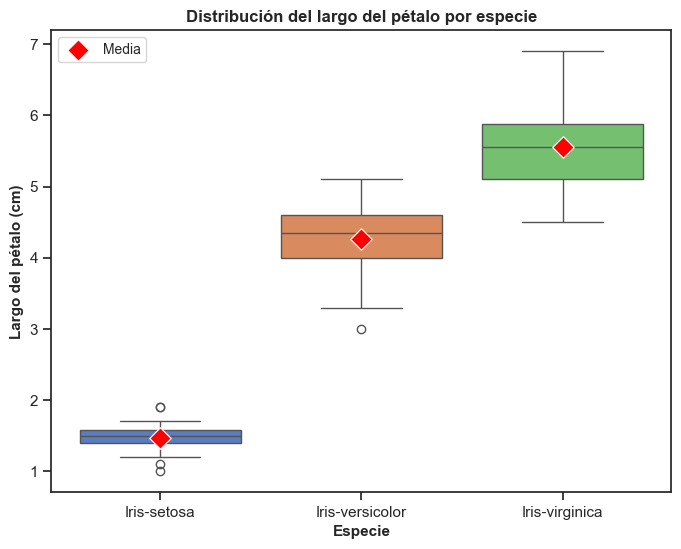

In [4]:
medias_iris = data_iris.groupby('species')['petal_length_cm'].mean().reset_index()

fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(x='species', y='petal_length_cm', data=data_iris, palette='muted', ax=ax)
sns.scatterplot(x='species', y='petal_length_cm', data=medias_iris,
                color='red', marker='D', s=120, zorder=5, ax=ax, label='Media')
ax.set_xlabel('Especie', fontweight='bold', fontsize=11)
ax.set_ylabel('Largo del pétalo (cm)', fontweight='bold', fontsize=11)
ax.set_title('Distribución del largo del pétalo por especie', fontweight='bold')
ax.legend(fontsize=10)
plt.show()

**Observación:** En *setosa* y *virginica* la media y la mediana son muy similares, lo que sugiere distribuciones aproximadamente simétricas. En *versicolor* la media es ligeramente superior a la mediana, indicando un leve sesgo a la derecha.

## Ítem 4 — Gráficos de violín en paneles (ancho de sépalo y pétalo)

C:\Users\PC\AppData\Local\Temp\ipykernel_16252\2805342358.py:6: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(x='sepal_width_cm', color='black', alpha=0.6, data=data_iris,
C:\Users\PC\AppData\Local\Temp\ipykernel_16252\2805342358.py:14: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(x='petal_width_cm', color='black', alpha=0.6, data=data_iris,


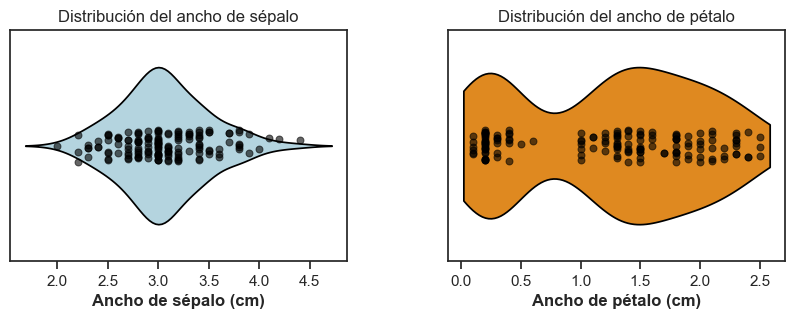

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
plt.subplots_adjust(hspace=0.5, wspace=0.3)

sns.violinplot(x='sepal_width_cm', color='lightblue', fill=True, data=data_iris,
               ax=axes[0], inner=None, linecolor='black', gap=0.15)
sns.stripplot(x='sepal_width_cm', color='black', alpha=0.6, data=data_iris,
              ax=axes[0], jitter=0.07, linewidth=0.7, edgecolor='gray')
axes[0].set_xlabel('Ancho de sépalo (cm)', fontweight='bold')
axes[0].set_yticks([])
axes[0].set_title('Distribución del ancho de sépalo')

sns.violinplot(x='petal_width_cm', color='darkorange', fill=True, data=data_iris,
               ax=axes[1], cut=0.3, inner=None, linecolor='black', gap=0.15)
sns.stripplot(x='petal_width_cm', color='black', alpha=0.6, data=data_iris,
              ax=axes[1], jitter=0.07, linewidth=0.7, edgecolor='gray')
axes[1].set_xlabel('Ancho de pétalo (cm)', fontweight='bold')
axes[1].set_title('Distribución del ancho de pétalo')
axes[1].set_yticks([])

plt.show()

**Análisis:**
- **Ancho de sépalo:** la distribución es aproximadamente *unimodal* y *simétrica* (forma similar a una campana).
- **Ancho de pétalo:** la distribución es claramente *bimodal*, con dos grupos bien diferenciados (uno concentrado cerca de 0.2 cm y otro entre 1.0 y 2.0 cm), lo que refleja la separación entre *setosa* y las otras dos especies.

## Ítem 5 — Relación entre ancho y largo del pétalo

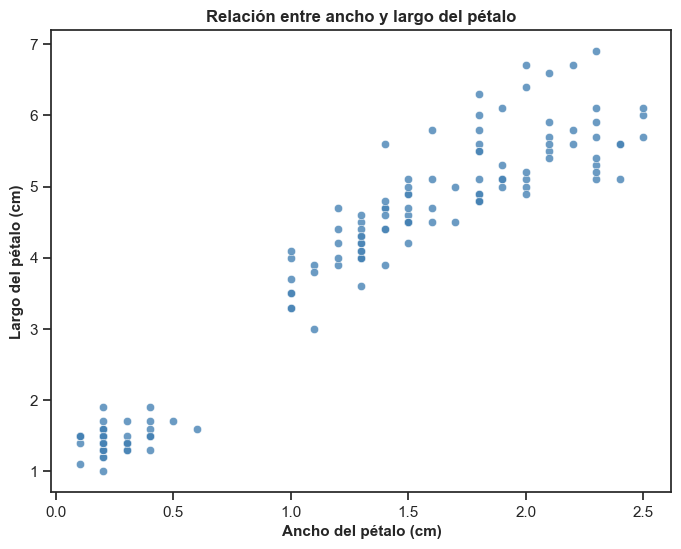

Correlación de Pearson (r): 0.963


In [6]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='petal_width_cm', y='petal_length_cm', data=data_iris,
                color='steelblue', edgecolor='white', alpha=0.8)
plt.xlabel('Ancho del pétalo (cm)', fontweight='bold', fontsize=11)
plt.ylabel('Largo del pétalo (cm)', fontweight='bold', fontsize=11)
plt.title('Relación entre ancho y largo del pétalo', fontweight='bold')
plt.show()

r = data_iris[['petal_width_cm', 'petal_length_cm']].corr().loc['petal_width_cm', 'petal_length_cm']
print(f'Correlación de Pearson (r): {r:.3f}')

**Observación:** Existe una asociación lineal positiva muy fuerte entre el ancho y el largo del pétalo (r ≈ 0.96). A mayor ancho de pétalo, mayor es también su largo.